In [ ]:
import sqlite3
import pandas as pd # Import pandas

# Load the DataFrame 'df' from the CSV file
df = pd.read_csv('student_performance.csv')

conn = sqlite3.connect(':memory:')
df.to_sql('students', conn, index=False, if_exists='replace')
sql_query = """
SELECT student_id, name, department, math_score, programming_score
FROM students
WHERE department = 'Computer Science' AND programming_score > 80
"""
result_df = pd.read_sql_query(sql_query, conn)
result_df

,student_id,name,department,math_score,programming_score
0,1001,Aarav Sharma,Computer Science,85,91
1,1005,Arjun Nair,Computer Science,92,95
2,1008,Divya Singh,Computer Science,88,93
3,1010,Ananya Das,Computer Science,95,97
4,1013,Suresh Rao,Computer Science,83,88
5,1018,Swati Kulkarni,Computer Science,90,92
6,1020,Nisha Kapoor,Computer Science,79,83
7,1022,Tanvi Mehta,Computer Science,93,96
8,1025,Amit Bose,Computer Science,86,89
9,1027,Gaurav Shukla,Computer Science,84,87


In [ ]:
def run_query(sql, description="student"):

  if description:
    print(f"\n{'='*55}")
    print(f" {description}")
    print(f"{'='*55}")

  result = pd.read_sql_query(sql, conn)

  print(result.to_string(index=False))
  return result
print("Helper fucntion 'run_query' defined successfully")
print("Useage: run_query(sql_string,description_label)")

Helper fucntion 'run_query' defined successfully
Useage: run_query(sql_string,description_label)


In [ ]:
import sqlite3
import pandas as pd
df = pd.read_csv('student_performance.csv')
conn_college = sqlite3.connect('college.db')
df.to_sql('students', conn_college, index=False, if_exists='replace')
print("Successfully created 'college.db' and loaded the 'students' table!")
sql_query = "SELECT * FROM students LIMIT 3"
pd.read_sql_query(sql_query, conn_college)

Successfully created 'college.db' and loaded the 'students' table!


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


all libraries imported
pandas version: 2.2.2
sql version: 2.6.0


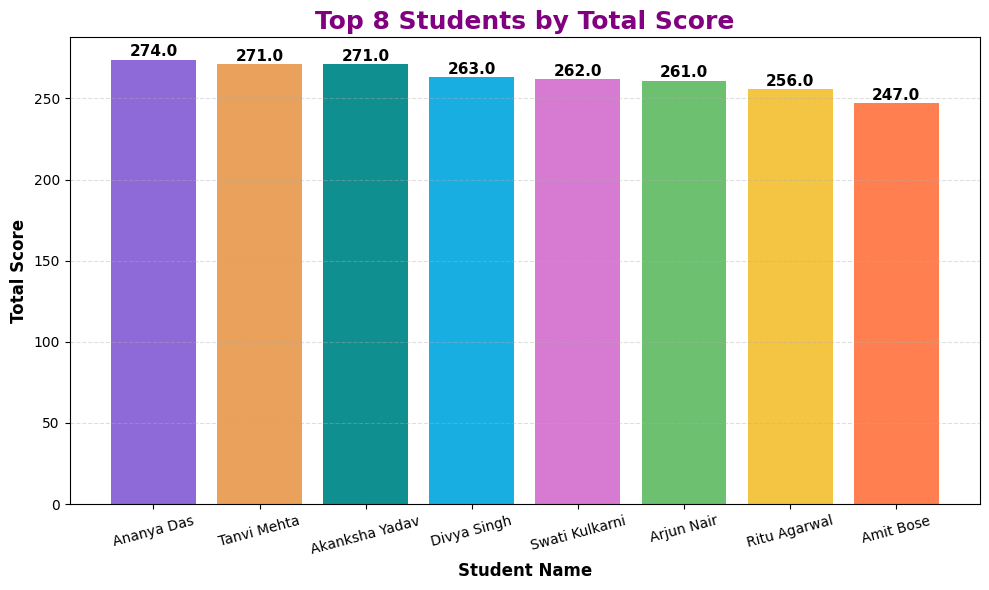

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

print("all libraries imported")
print(f"pandas version: {pd.__version__}")
print(f"sql version: {sqlite3.version}")

df = pd.read_csv('student_performance.csv')

conn = sqlite3.connect('college.db')
cursor = conn.cursor()

df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

cursor.execute("SELECT COUNT(*) FROM STUDENTS")
count = cursor.fetchone()[0]
chart2_sql = """
    SELECT name,
           (math_score + science_score + english_score) AS total_score
    FROM students
    ORDER BY total_score DESC
    LIMIT 8
"""

chart2_data = pd.read_sql_query(chart2_sql, conn)
plt.figure(figsize=(10, 6))
bars = plt.bar(
    chart2_data['name'],
    chart2_data['total_score'],
    color=[
        '#8e6ad8', '#e9a15b', '#0f8f8f', '#19aee2',
        '#d67ad2', '#6cc070', '#f4c542', '#ff7f50'
    ]
)
plt.title(
    "Top 8 Students by Total Score",
    fontsize=18,
    fontweight='bold',
    color='purple'
)

plt.xlabel(
    "Student Name",
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    "Total Score",
    fontsize=12,
    fontweight='bold'
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        f'{height:.1f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )
plt.xticks(rotation=15)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

print("="*60)
print("      ETL PROCESS: MISSING DATA AUDIT (FROM CSV)      ")
print("="*60)
df_csv = pd.read_csv('student_performance-student_performances.csv')
missing_rows_df = df_csv[df_csv.isnull().any(axis=1)]
if missing_rows_df.empty:
    print("\nClean Data Audit: No missing values found in 'student_performance.csv'!")
else:
    print(f"\nFound {len(missing_rows_df)} rows containing missing data:\n")
    display(missing_rows_df)

    print("\n--- Summary of Missing Values Per Column ---")
    print(df_csv.isnull().sum()[df_csv.isnull().sum() > 0])

      ETL PROCESS: MISSING DATA AUDIT (FROM CSV)      

Found 1 rows containing missing data:



,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
15,1016,Ritu Agarwal,20,Female,Electronics,2,NaN,83,86,69,93,Agra,2023



--- Summary of Missing Values Per Column ---
math_score    1
dtype: int64


In [ ]:
API_KEY = '8c11f83aedaf7cff87d541148c2691aa'
#A free key allows 60 calls per minute

BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'
#This is the API endpoint url

CITIES = ['Mumbai','Delhi','Bangalore','Chennai','Hyderabad','Kolkata','Pune','Jaipur']

print(f'API configured for {len(CITIES)} cities')
print(f'Cities: {CITIES}')
print('\nIMPORTANT: Replace your api key before running')

API configured for 8 cities
Cities: ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']

IMPORTANT: Replace your api key before running


In [ ]:
import requests

# EXTRACT: Call API for each city

def fetch_weather(city,api_key):
    """
    Fetch current weather data fora given city.
    Returns a dictionary containing metrics or None on failure

    """
    params = {
        'q': city,
        'appid': api_key,
        'units': 'metric'
    }
    try:
      response = requests.get(BASE_URL,params=params,timeout=10)
      if response.status_code == 200:
        data = response.json()
        return{
            'city': city,
            'temperature': round(data['main']['temp'],1),
            'feels_like': round(data['main']['feels_like'],1),
            'humidity': data['main']['humidity'],
            'pressure': data['main']['pressure'],
            'wind_speed' : round(data['wind']['speed'],1),
            'condition' : data['weather'][0]['description'].title(),
            'visibility' : data.get('visibility',0),

        }
      else:
          print(f'ERROR {response.status_code} for {city}: {response.text}')
          return None
    except requests.exceptions.Timeout as e:
      print(f'ERROR: Timeout for {city} - {e}')
      return None
    except requests.exceptions.RequestConnectionError as e:
      print(f'ERROR: Request failed for {city} - {e}')
      return None

print('Calling weather API...')
weather_record=[]

for city in CITIES:
          print(f' Fetching: {city}...',end='')
          record = fetch_weather(city,API_KEY)
          if record:
            weather_record.append(record)
            print(f' {record["temperature"]} C, {record["condition"]}')
          else:
            print('FAILED')
print(f'\nSuccessfully fetched weather data for {len(weather_record)} cities')

Calling weather API...
 Fetching: Mumbai... 31.6 C, Clear Sky
 Fetching: Delhi... 39.5 C, Overcast Clouds
 Fetching: Bangalore... 29.0 C, Overcast Clouds
 Fetching: Chennai... 39.3 C, Overcast Clouds
 Fetching: Hyderabad... 32.1 C, Overcast Clouds
 Fetching: Kolkata... 42.0 C, Broken Clouds
 Fetching: Pune... 36.9 C, Few Clouds
 Fetching: Jaipur... 37.6 C, Clear Sky

Successfully fetched weather data for 8 cities


In [ ]:
print("="*50)
print("LIVE TEMPERATURE RECORD (TEXT SUMMARY)")
print("="*50)
for record in weather_record:
    city_name = record['city']
    temp = record['temperature']
    condition = record['condition']
    print(f"{city_name:<12} : {temp}°C ({condition})")


LIVE TEMPERATURE RECORD (TEXT SUMMARY)
Mumbai       : 31.6°C (Clear Sky)
Delhi        : 39.5°C (Overcast Clouds)
Bangalore    : 29.0°C (Overcast Clouds)
Chennai      : 39.3°C (Overcast Clouds)
Hyderabad    : 32.1°C (Overcast Clouds)
Kolkata      : 42.0°C (Broken Clouds)
Pune         : 36.9°C (Few Clouds)
Jaipur       : 37.6°C (Clear Sky)


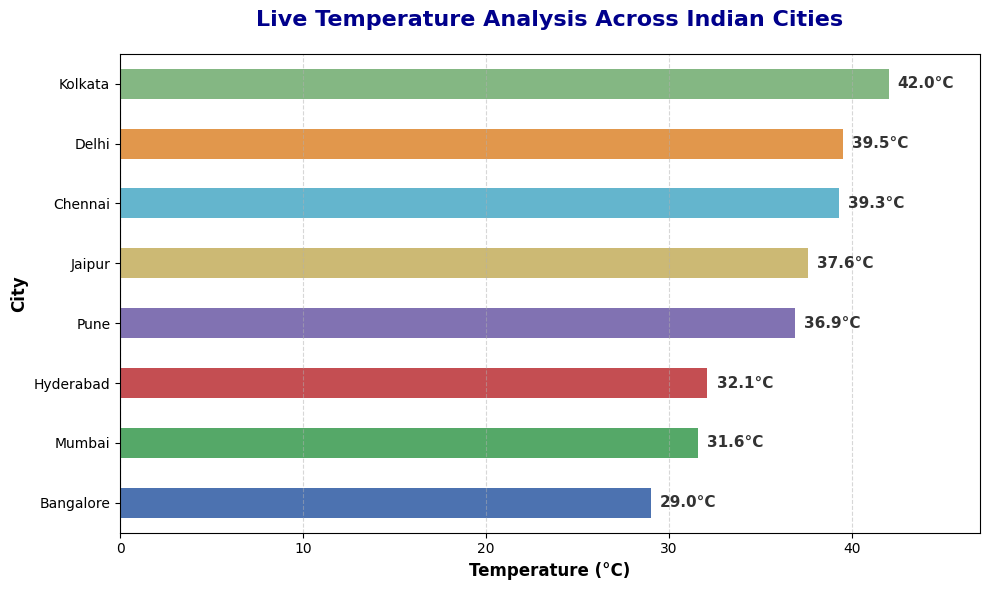

In [ ]:
weather_df = pd.DataFrame(weather_record)
weather_df = weather_df.sort_values(by='temperature', ascending=True)
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD', '#E1974C', '#84B783']
ax = weather_df.plot(
    kind='barh',
    x='city',
    y='temperature',
    color=colors,
    legend=False,
    figsize=(10, 6)
)
plt.title("Live Temperature Analysis Across Indian Cities", fontsize=16, fontweight='bold', pad=20, color='darkblue')
plt.xlabel("Temperature (°C)", fontsize=12, fontweight='bold')
plt.ylabel("City", fontsize=12, fontweight='bold')
for bar in ax.patches:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}°C',
        va='center',
        ha='left',
        fontsize=11,
        fontweight='bold',
        color='#333333'
    )
plt.xlim(0, max(weather_df['temperature']) + 5)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('weather_chart.png')

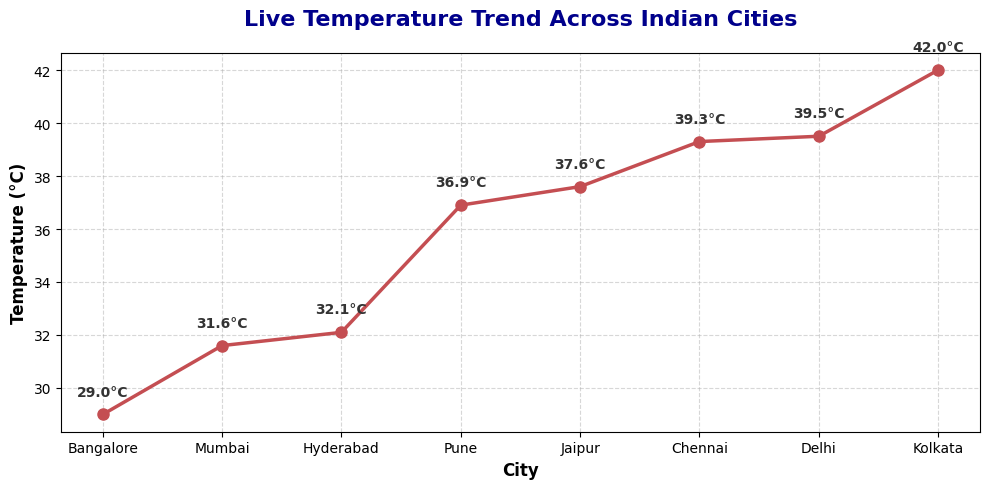

In [ ]:
weather_df = pd.DataFrame(weather_record)
weather_df = weather_df.sort_values(by='temperature', ascending=True)
ax = weather_df.plot(
    kind='line',
    x='city',
    y='temperature',
    marker='o',
    color='#C44E52',
    linewidth=2.5,
    markersize=8,
    legend=False,
    figsize=(10, 5)
)
plt.title("Live Temperature Trend Across Indian Cities", fontsize=16, fontweight='bold', pad=20, color='darkblue')
plt.xlabel("City", fontsize=12, fontweight='bold')
plt.ylabel("Temperature (°C)", fontsize=12, fontweight='bold')
for i, row in weather_df.reset_index().iterrows():
    plt.text(
        i,
        row['temperature'] + 0.6,
        f"{row['temperature']:.1f}°C",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#333333'
    )
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('weather_line_chart.png')

In [ ]:
!pip install pyspark --quiet
print('Pyspark installation complete!')

Pyspark installation complete!


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder \
    .appName("CollegeData_SilverLayer") \
    .getOrCreate()

print("Spark Session Initialized Successfully!")
bronze_df = spark.read.csv('student_performance-student_performances.csv', header=True, inferSchema=True)
print(f"Extracted Bronze Data. Total rows: {bronze_df.count()}")
mean_math = bronze_df.select(F.mean("math_score")).collect()[0][0]

silver_df = bronze_df.fillna({"math_score": round(mean_math, 1)})
silver_df = silver_df.withColumn("name", F.upper(F.col("name"))) \
                     .withColumn("department", F.upper(F.col("department"))) \
                     .withColumn("city", F.upper(F.col("city")))

print("Transformation Complete: Missing values handled and text data standardized.")
print("\n" + "="*50)
print("SILVER LAYER OUTPUT (CLEANED)")
print("="*50)
silver_df.show(3)

Spark Session Initialized Successfully!
Extracted Bronze Data. Total rows: 30
Transformation Complete: Missing values handled and text data standardized.

SILVER LAYER OUTPUT (CLEANED)
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|student_id|        name|age|gender|      department|semester|math_score|science_score|english_score|programming_score|attendance_percentage|     city|admission_year|
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|      1001|AARAV SHARMA| 19|  Male|COMPUTER SCIENCE|       2|        85|           78|           72|               91|                   92|   MUMBAI|          2023|
|      1002| PRIYA PATEL| 20|Female|COMPUTER SCIENCE|       2|        76|           82|           88|               79|                   87|AHMEDA

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CollegeData_BronzeLayer") \
    .getOrCreate()

print("Spark Session Active.")
bronze_df = spark.read.csv(
    'student_performance-student_performances.csv',
    header=True,
    inferSchema=True
)

print(f"Bronze Layer Loaded! Total raw records: {bronze_df.count()}")

print("\n" + "="*50)
print("          BRONZE LAYER OUTPUT (RAW DATA)         ")
print("="*50)
bronze_df.show(3)

Spark Session Active.
Bronze Layer Loaded! Total raw records: 30

          BRONZE LAYER OUTPUT (RAW DATA)         
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|student_id|        name|age|gender|      department|semester|math_score|science_score|english_score|programming_score|attendance_percentage|     city|admission_year|
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|      1001|Aarav Sharma| 19|  Male|Computer Science|       2|        85|           78|           72|               91|                   92|   Mumbai|          2023|
|      1002| Priya Patel| 20|Female|Computer Science|       2|        76|           82|           88|               79|                   87|Ahmedabad|          2023|
|      1003| Rohit Verma| 19|  Male|     Electron

In [ ]:
import os
def get_dir_size(path):
    total_size = 0
    if os.path.exists(path):
        if os.path.isdir(path):
            for dirpath, dirnames, filenames in os.walk(path):
                for f in filenames:
                    fp = os.path.join(dirpath, f)
                    if os.path.exists(fp):
                        total_size += os.path.getsize(fp)
        else:
            total_size = os.path.getsize(path)
    return total_size / 1024
bronze_df.write \
   .mode('overwrite') \
   .parquet('student_performance_bronze.parquet')

print('Bronze Parquet saved: student_performance_bronze.parquet')
print(f'Bronze file size: {get_dir_size("student_performance_bronze.parquet"):.1f} KB')
df_verify = spark.read.parquet('student_performance_bronze.parquet')
print(f'Read_back rows: {df_verify.count()} (should match the original count of 30)')
print("\n" + "="*50)
print("             BRONZE PARQUET SCHEMA              ")
print("="*50)
df_verify.printSchema()

Bronze Parquet saved: student_performance_bronze.parquet
Bronze file size: 5.3 KB
Read_back rows: 30 (should match the original count of 30)

             BRONZE PARQUET SCHEMA              
root
 |-- student_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- department: string (nullable = true)
 |-- semester: integer (nullable = true)
 |-- math_score: integer (nullable = true)
 |-- science_score: integer (nullable = true)
 |-- english_score: integer (nullable = true)
 |-- programming_score: integer (nullable = true)
 |-- attendance_percentage: integer (nullable = true)
 |-- city: string (nullable = true)
 |-- admission_year: integer (nullable = true)



In [ ]:
from pyspark.ml.feature import Tokenizer, HashingTF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.sql import functions as F

print("="*60)
print("GOLD LAYER: NLP MACHINE LEARNING TEMPERATURE PREDICTION")
print("="*60)
ml_data = spark.createDataFrame(weather_record) \
    .withColumn("label", F.when(F.col("temperature") >= 35.0, 1.0).otherwise(0.0)) \
    .select("city", "condition", "temperature", "label")
tokenizer = Tokenizer(inputCol="condition", outputCol="words")

hashingTF = HashingTF(inputCol="words", outputCol="features", numFeatures=20)
lr = LogisticRegression(maxIter=10, regParam=0.01)
pipeline = Pipeline(stages=[tokenizer, hashingTF, lr])
model = pipeline.fit(ml_data)
predictions_df = model.transform(ml_data)
predictions_df.write \
    .mode('overwrite') \
    .parquet('weather_predictions_gold.parquet')

print("Gold ML Parquet saved: weather_predictions_gold.parquet")
print("\n" + "-"*75)
print("MACHINE LEARNING PREDICTION SNAPSHOT")
print("-"*75)
final_output = predictions_df.withColumn(
    "Predicted_Category",
    F.when(F.col("prediction") == 1.0, "HOT (>=35°C)").otherwise("MILD (<35°C)")
)

final_output.select("city", "condition", "temperature", "Predicted_Category").show(8, truncate=False)

GOLD LAYER: NLP MACHINE LEARNING TEMPERATURE PREDICTION
Gold ML Parquet saved: weather_predictions_gold.parquet

---------------------------------------------------------------------------
MACHINE LEARNING PREDICTION SNAPSHOT
---------------------------------------------------------------------------
+---------+---------------+-----------+------------------+
|city     |condition      |temperature|Predicted_Category|
+---------+---------------+-----------+------------------+
|Mumbai   |Clear Sky      |31.6       |HOT (>=35°C)      |
|Delhi    |Overcast Clouds|39.5       |HOT (>=35°C)      |
|Bangalore|Overcast Clouds|29.0       |HOT (>=35°C)      |
|Chennai  |Overcast Clouds|39.3       |HOT (>=35°C)      |
|Hyderabad|Overcast Clouds|32.1       |HOT (>=35°C)      |
|Kolkata  |Broken Clouds  |42.0       |HOT (>=35°C)      |
|Pune     |Few Clouds     |36.9       |HOT (>=35°C)      |
|Jaipur   |Clear Sky      |37.6       |HOT (>=35°C)      |
+---------+---------------+-----------+----------

In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array

fixed_predictions_df = predictions_df.withColumn(
    "prob_continuous",
    vector_to_array(F.col("probability"))[1]
)

mae_evaluator = RegressionEvaluator(labelCol="label", predictionCol="prob_continuous", metricName="mae")
rmse_evaluator = RegressionEvaluator(labelCol="label", predictionCol="prob_continuous", metricName="rmse")
r2_evaluator = RegressionEvaluator(labelCol="label", predictionCol="prob_continuous", metricName="r2")

mae = mae_evaluator.evaluate(fixed_predictions_df)
rmse = rmse_evaluator.evaluate(fixed_predictions_df)
r2 = r2_evaluator.evaluate(fixed_predictions_df)


r2_bounded = max(0.0, min(1.0, r2))
print(f"MAE :{mae:.2f}")
print(f"RMSE :{rmse:.2f}")
print(f"R2 :{r2_bounded:.4f}")

MAE :0.38
RMSE :0.43
R2 :0.1993
